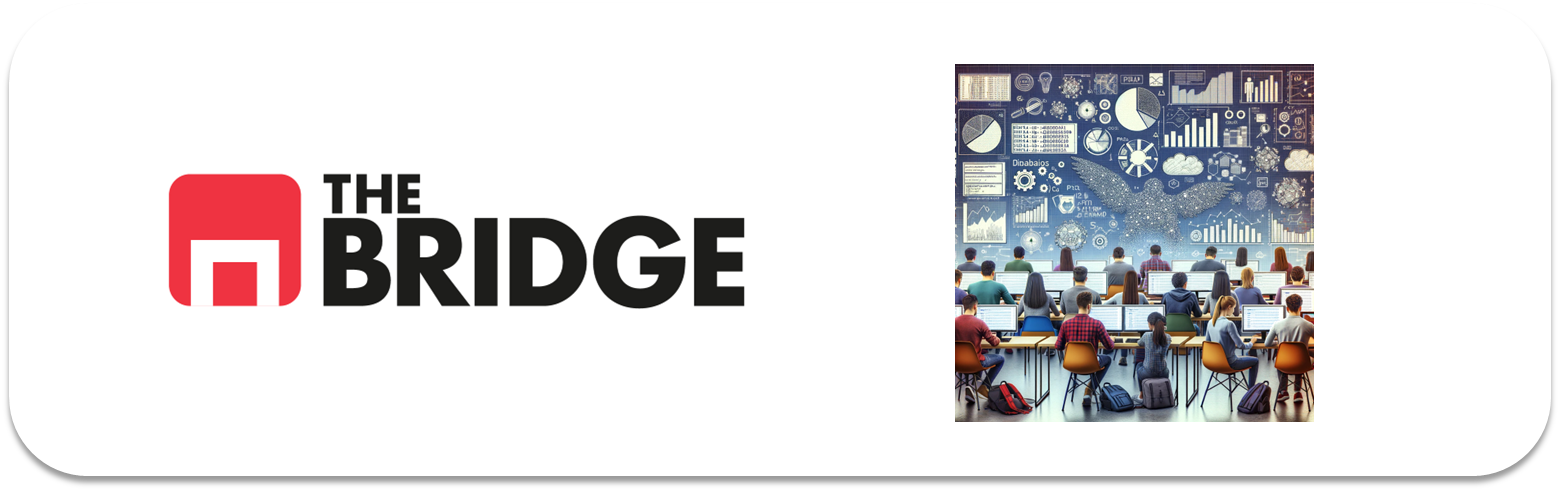

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [2]:
# Imports principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### 1. Carga del dataset


In [3]:

df = pd.read_csv('data/hard_to_find/obligatoria_hard.csv', sep='|')

print(df.shape)
display(df.head())
display(df.info())
display(df.isna().sum())

(506, 13)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.0063,18.0000,2.3100,0.0000,0.5380,6.5750,65.2000,4.0900,1.0000,296.0000,15.3000,4.9800,24.0000
1,0.0273,0.0000,7.0700,0.0000,0.4690,6.4210,78.9000,4.9671,2.0000,242.0000,17.8000,9.1400,21.6000
2,0.0273,0.0000,7.0700,0.0000,0.4690,7.1850,61.1000,4.9671,2.0000,242.0000,17.8000,4.0300,34.7000
3,0.0324,0.0000,2.1800,0.0000,0.4580,6.9980,45.8000,6.0622,3.0000,222.0000,18.7000,2.9400,33.4000
4,0.0691,0.0000,2.1800,0.0000,0.4580,7.1470,54.2000,6.0622,3.0000,222.0000,18.7000,5.3300,36.2000


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


None

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
LSTAT      0
MEDV       0
dtype: int64

In [4]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
CRIM,506.0000,3.6135,8.6015,0.0063,0.0820,0.2565,3.6771,88.9762
ZN,506.0000,11.3636,23.3225,0.0000,0.0000,0.0000,12.5000,100.0000
INDUS,506.0000,11.1368,6.8604,0.4600,5.1900,9.6900,18.1000,27.7400
CHAS,506.0000,0.0692,0.2540,0.0000,0.0000,0.0000,0.0000,1.0000
NOX,506.0000,0.5547,0.1159,0.3850,0.4490,0.5380,0.6240,0.8710
RM,506.0000,6.2846,0.7026,3.5610,5.8855,6.2085,6.6235,8.7800
AGE,506.0000,68.5749,28.1489,2.9000,45.0250,77.5000,94.0750,100.0000
DIS,506.0000,3.7950,2.1057,1.1296,2.1002,3.2074,5.1884,12.1265
RAD,506.0000,9.5494,8.7073,1.0000,4.0000,5.0000,24.0000,24.0000
TAX,506.0000,408.2372,168.5371,187.0000,279.0000,330.0000,666.0000,711.0000


### 2. Elección y análisis de la variable target


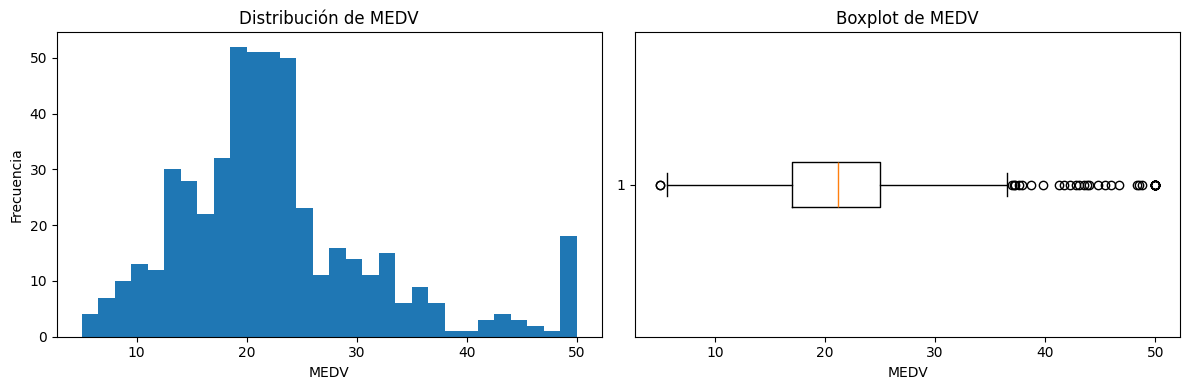

count   506.0000
mean     22.5328
std       9.1971
min       5.0000
25%      17.0250
50%      21.2000
75%      25.0000
max      50.0000
Name: MEDV, dtype: float64

Número de registros con MEDV = 50: 16


In [5]:
target = 'MEDV'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[target], bins=30)
axes[0].set_title('Distribución de MEDV')
axes[0].set_xlabel('MEDV')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df[target], vert=False)
axes[1].set_title('Boxplot de MEDV')
axes[1].set_xlabel('MEDV')

plt.tight_layout()
plt.show()

print(df[target].describe())
print()
print('Número de registros con MEDV = 50:', (df[target] == 50).sum())


### 3 Split train/test y construcción de X, y

In [6]:
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (404, 12)
X_test : (102, 12)
y_train: (404,)
y_test : (102,)


### 4. Mini-EDA y selección de variables


,corr_con_MEDV
MEDV,1.0000
RM,0.6954
ZN,0.3604
DIS,0.2499
CHAS,0.1753
AGE,-0.3770
RAD,-0.3816
CRIM,-0.3883
NOX,-0.4273
TAX,-0.4685


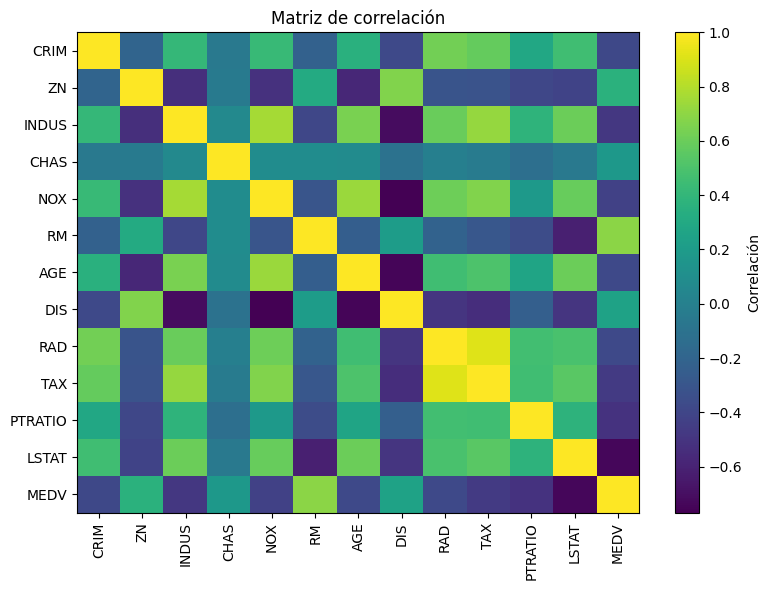

In [7]:
corr = df.corr(numeric_only=True)
target_corr = corr[target].sort_values(ascending=False)
display(target_corr.to_frame('corr_con_MEDV'))

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlación')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

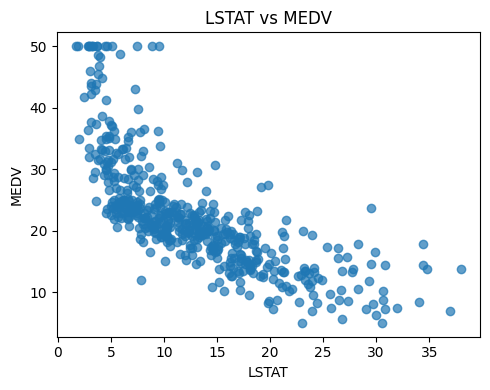

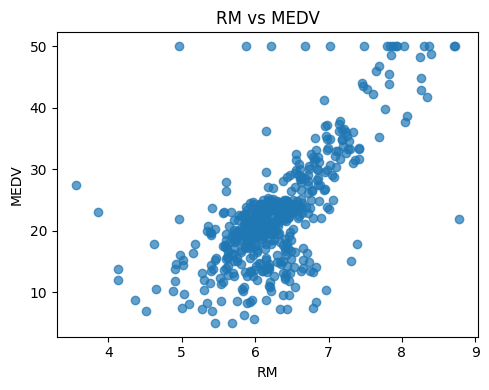

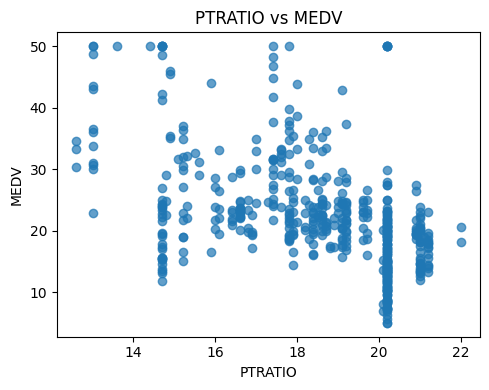

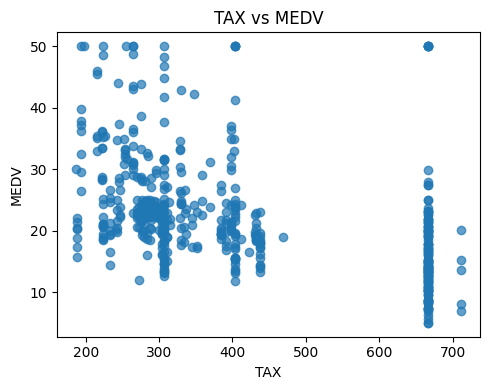

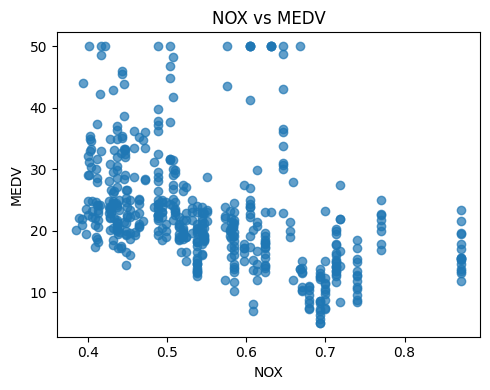

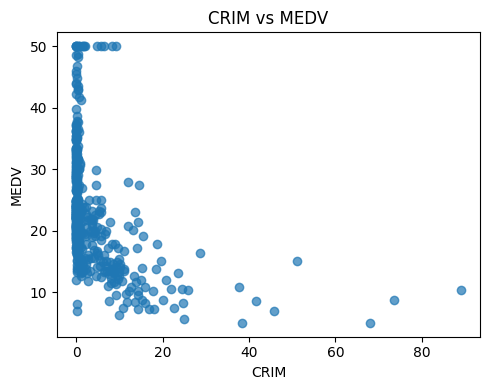

In [8]:
# Visualizamos las relaciones más importantes con el target
important_features = ['LSTAT', 'RM', 'PTRATIO', 'TAX', 'NOX', 'CRIM']

for col in important_features:
    plt.figure(figsize=(5, 4))
    plt.scatter(df[col], df[target], alpha=0.7)
    plt.title(f'{col} vs {target}')
    plt.xlabel(col)
    plt.ylabel(target)
    plt.tight_layout()
    plt.show()

### 6. Modelo de regresión lineal base


In [9]:

linear_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

### 7. Evaluación del modelo


In [10]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_true, y_pred)
    }

results = []
results.append({'Modelo': 'LinearRegression', **regression_metrics(y_test, y_pred_linear)})

metrics_df = pd.DataFrame(results)
display(metrics_df)


,Modelo,MAE,MSE,RMSE,R2
0,LinearRegression,3.1114,22.7777,4.7726,0.6894


##### Análisis de pesos e importancia de variables


,coeficiente
LSTAT,-3.8190
DIS,-3.1195
RM,3.0044
NOX,-2.1376
RAD,2.0589
PTRATIO,-1.9919
TAX,-1.8713
CRIM,-1.1275
CHAS,0.7872
ZN,0.7121


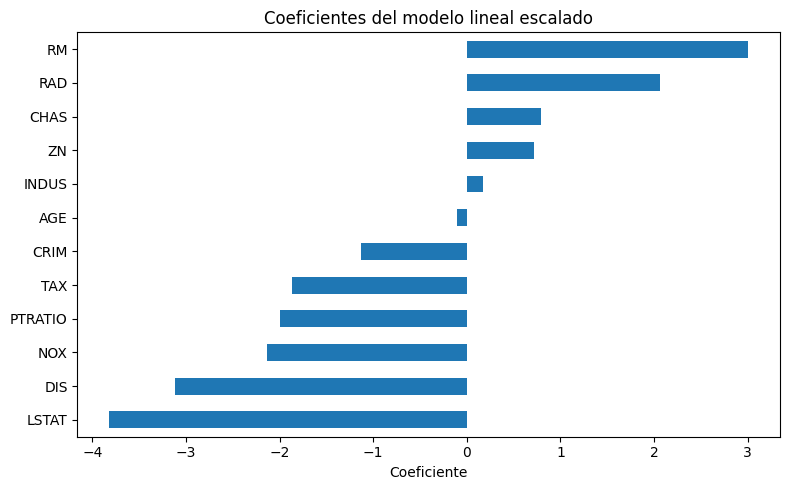

In [11]:

coefs = pd.Series(
    linear_model.named_steps['model'].coef_,
    index=X_train.columns,
    name='coeficiente'
).sort_values(key=np.abs, ascending=False)

display(coefs.to_frame())

plt.figure(figsize=(8, 5))
coefs.sort_values().plot(kind='barh')
plt.title('Coeficientes del modelo lineal escalado')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()


### 8. Comparación gráfica entre predicciones y valores reales


,real,pred_linear,error
0,24.0000,29.9834,-5.9834
2,34.7000,31.2396,3.4604
9,18.9000,18.3883,0.5117
11,18.9000,21.0221,-2.1221
18,20.2000,17.1501,3.0499
22,15.2000,15.7612,-0.5612
30,12.7000,11.4846,1.2154
33,13.1000,14.3667,-1.2667
39,30.8000,30.7182,0.0818
46,20.0000,20.3794,-0.3794


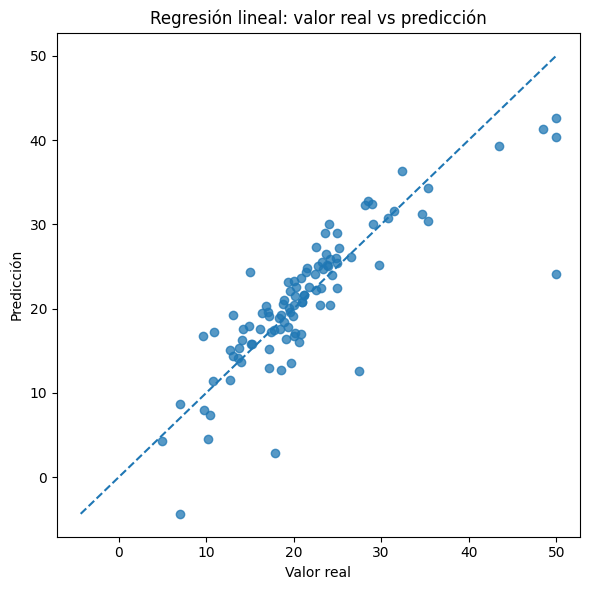

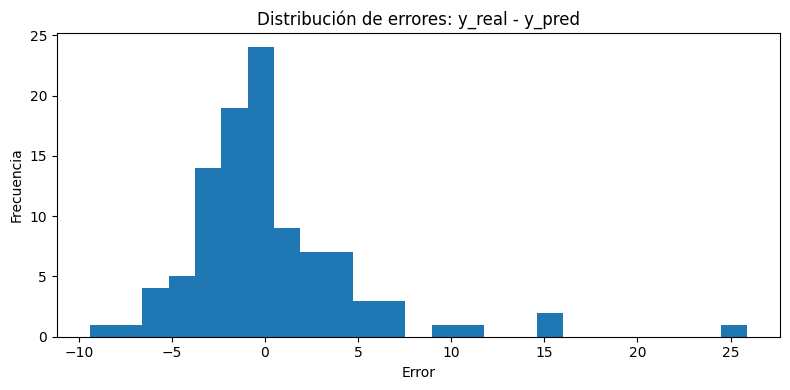

In [12]:

comparison = pd.DataFrame({
    'real': y_test,
    'pred_linear': y_pred_linear,
    'error': y_test - y_pred_linear
}).sort_index()

display(comparison.head(15))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_linear, alpha=0.75)
min_val = min(y_test.min(), y_pred_linear.min())
max_val = max(y_test.max(), y_pred_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.xlabel('Valor real')
plt.ylabel('Predicción')
plt.title('Regresión lineal: valor real vs predicción')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(comparison['error'], bins=25)
plt.title('Distribución de errores: y_real - y_pred')
plt.xlabel('Error')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


### 9. Regularización


In [13]:

alphas = [0.01, 0.1, 1, 10, 100]

regularized_results = []
trained_models = {'LinearRegression': linear_model}

for alpha in alphas:
    ridge = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha))
    ])
    ridge.fit(X_train, y_train)
    pred = ridge.predict(X_test)
    regularized_results.append({'Modelo': f'Ridge alpha={alpha}', **regression_metrics(y_test, pred)})
    trained_models[f'Ridge alpha={alpha}'] = ridge

for alpha in alphas:
    lasso = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=alpha, max_iter=10000))
    ])
    lasso.fit(X_train, y_train)
    pred = lasso.predict(X_test)
    regularized_results.append({'Modelo': f'Lasso alpha={alpha}', **regression_metrics(y_test, pred)})
    trained_models[f'Lasso alpha={alpha}'] = lasso

all_results = pd.concat([
    metrics_df,
    pd.DataFrame(regularized_results)
], ignore_index=True).sort_values('RMSE')

display(all_results)


,Modelo,MAE,MSE,RMSE,R2
0,LinearRegression,3.1114,22.7777,4.7726,0.6894
1,Ridge alpha=0.01,3.1113,22.7780,4.7726,0.6894
2,Ridge alpha=0.1,3.1110,22.7811,4.7730,0.6894
3,Ridge alpha=1,3.1074,22.8111,4.7761,0.6889
6,Lasso alpha=0.01,3.1046,22.8535,4.7805,0.6884
4,Ridge alpha=10,3.0859,23.0926,4.8055,0.6851
7,Lasso alpha=0.1,3.1677,24.4136,4.9410,0.6671
5,Ridge alpha=100,3.1093,24.5316,4.9529,0.6655
8,Lasso alpha=1,3.4592,27.3538,5.2301,0.6270
9,Lasso alpha=10,6.2558,75.0454,8.6629,-0.0233


##### Búsqueda de hiperparámetro con validación cruzada


In [14]:

ridge_grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ]),
    param_grid={'model__alpha': alphas},
    scoring='neg_root_mean_squared_error',
    cv=5
)

ridge_grid.fit(X_train, y_train)

print('Mejor alpha Ridge:', ridge_grid.best_params_['model__alpha'])
print('Mejor RMSE medio CV:', -ridge_grid.best_score_)

y_pred_best_ridge = ridge_grid.predict(X_test)
best_ridge_metrics = regression_metrics(y_test, y_pred_best_ridge)
display(pd.DataFrame([{'Modelo': 'Best Ridge CV', **best_ridge_metrics}]))


Mejor alpha Ridge: 1
Mejor RMSE medio CV: 4.911986005978767


,Modelo,MAE,MSE,RMSE,R2
0,Best Ridge CV,3.1074,22.8111,4.7761,0.6889


In [15]:
cv_results = pd.DataFrame(ridge_grid.cv_results_)
cv_results = cv_results[['param_model__alpha', 'mean_test_score', 'std_test_score']].copy()
cv_results['mean_RMSE_CV'] = -cv_results['mean_test_score']
cv_results['std_RMSE_CV'] = cv_results['std_test_score']
cv_results = cv_results.drop(columns=['mean_test_score', 'std_test_score'])
display(cv_results.sort_values('mean_RMSE_CV'))

,param_model__alpha,mean_RMSE_CV,std_RMSE_CV
2,1.0000,4.9120,0.5197
1,0.1000,4.9123,0.5189
0,0.0100,4.9123,0.5188
3,10.0000,4.9191,0.5227
4,100.0000,5.1324,0.4573


##### Comparación visual del mejor modelo regularizado


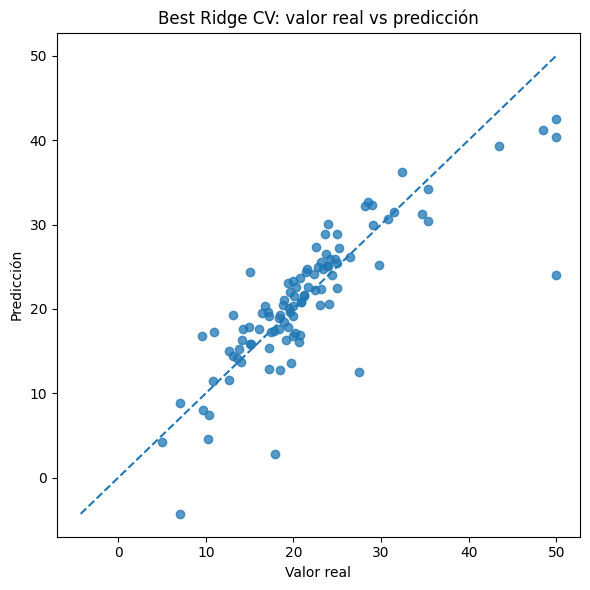

,coeficiente_ridge
LSTAT,-3.8043
DIS,-3.0816
RM,3.0123
NOX,-2.1053
RAD,1.9825
PTRATIO,-1.9824
TAX,-1.8010
CRIM,-1.1172
CHAS,0.7905
ZN,0.6931


In [16]:

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best_ridge, alpha=0.75)
min_val = min(y_test.min(), y_pred_best_ridge.min())
max_val = max(y_test.max(), y_pred_best_ridge.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.xlabel('Valor real')
plt.ylabel('Predicción')
plt.title('Best Ridge CV: valor real vs predicción')
plt.tight_layout()
plt.show()

best_ridge_coefs = pd.Series(
    ridge_grid.best_estimator_.named_steps['model'].coef_,
    index=X_train.columns,
    name='coeficiente_ridge'
).sort_values(key=np.abs, ascending=False)

display(best_ridge_coefs.to_frame())


### 10. Conclusiones

- El problema es adecuado para regresión porque `MEDV` es una variable numérica continua.
- Las variables más relacionadas con el precio son `LSTAT` de forma negativa y `RM` de forma positiva.
- El modelo lineal base consigue un rendimiento razonable en test, aunque no perfecto. El dataset tiene relaciones no completamente lineales y el target está censurado en 50, lo que limita el ajuste de una regresión lineal simple.
- Ridge con valores bajos de `alpha` obtiene resultados muy similares a la regresión lineal. Esto indica que la regularización no mejora de forma drástica, pero ayuda a controlar coeficientes y multicolinealidad.
- Lasso con `alpha` alto empeora porque elimina o reduce demasiado algunas variables útiles.

**Modelo elegido:** me quedaría con `Ridge` seleccionado por validación cruzada. Aunque sus métricas son prácticamente equivalentes a la regresión lineal base, es una opción más robusta ante multicolinealidad y mantiene el modelo estable sin perder interpretabilidad.